# This notebook preprocesses the raw data
### from quality control to creating a clean aggregate data set

Input: raw data in the raw_data folder

Output: clean data in csv form in processed_data folder

Imports

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt
import numpy as np
from scipy.io import loadmat
import pickle as pkl

Set global variables and propertes

In [2]:
raw_data_fname_str = ""
raw_data_folder = "raw_data"

results_folder = "results"

processed_data_folder = "processed_data"

full_data_fname = "full_data.csv"
full_data_file = os.path.join(processed_data_folder, full_data_fname)

mask_file_name = "mask.txt"
mask_file = os.path.join(processed_data_folder, mask_file_name)

structured_data_fname = "structured_data.pkl"
structured_data_file = os.path.join(processed_data_folder, structured_data_fname)

statistics_folder = os.path.join(results_folder, "statistics")

In [3]:
trials =  150#number of trials
T = 3 #number of time steps in each trial
nb = 4 # number of bandits, ie second level rewards
ns = 3+nb #number of states
no = ns #number of observations
na = 2 #number of actions
npi = na**(T-1) #number of policies
nr = 2 #number of rewards
never_reward = ns-nb # states that dont generate rewards

# make global parameter dict:
global_experiment_parameters = {"trials": trials, "T": T, "nb": nb, "ns": ns, "no": no, "na": na, "npi": npi, "nr": nr, "never_reward": never_reward}

In [4]:
n_subjects = 206

In [5]:
# index definitions taken from make_raw_data.m

stim_1_left_i = 1
stim_1_right_i = 2
rt_1_i = 3
choice1_i = 4
stim_2_left_i = 5
stim_2_right_i = 6
rt_2_i = 7
choice2_i = 8
win_i = 9
state2_i = 10
common_i = 11
score_i = 12
practice_i = 13
ps1a1_i = 14
ps1a2_i = 15
ps2a1_i = 16
ps2a2_i = 17
trial_i = 18

In [6]:
fname = os.path.join("raw_data", "data.mat")

dataset = loadmat(fname)

In [7]:
print(dataset["data"][-1])

[array(['subject_206'], dtype='<U11') array([[1]], dtype=uint8)
 array([[2]], dtype=uint8) array([[772]], dtype=uint16)
 array([[1]], dtype=uint8) array([[1]], dtype=uint8)
 array([[2]], dtype=uint8) array([[1075]], dtype=uint16)
 array([[1]], dtype=uint8) array([[1]], dtype=uint8)
 array([[1]], dtype=uint8) array([[1]], dtype=uint8)
 array([[52]], dtype=uint8) array([[0]], dtype=uint8)
 array([[0.33220588]]) array([[0.6790932]]) array([[0.7290318]])
 array([[0.43025198]]) array([[124]], dtype=uint8)
 array([[2080004]], dtype=int32)]


In [8]:
trial_arr = np.stack([np.concat([dataset["data"][(j*trials)+i][trial_i] for i in range(trials)]).flatten() for j in range(n_subjects)], axis=-1)

print(trial_arr.shape)

(150, 206)


In [9]:
subject_arr = np.array(list(range(n_subjects)))

In [10]:
actions_stage1 = np.stack([np.concat([dataset["data"][(j*trials)+i][choice1_i] for i in range(trials)]).flatten() for j in range(n_subjects)], axis=-1) - 1

actions_stage2 = np.stack([np.concat([dataset["data"][(j*trials)+i][choice2_i] for i in range(trials)]).flatten() for j in range(n_subjects)], axis=-1) - 1

valid_a1 = actions_stage1>=0
valid_a2 = actions_stage2>=0
valid = np.logical_and(valid_a1, valid_a2)

actions_stage1[np.logical_not(valid)] = 0
actions_stage2[np.logical_not(valid)] = 0

actions = np.stack([actions_stage1, actions_stage2], axis=1)

# actions[actions<0] = 0

print(actions.shape)

print(np.unique(actions))

(150, 2, 206)
[0 1]


In [11]:
rewards_stage1 = np.ones_like(actions_stage1)

rewards_stage2 = np.stack([np.concat([dataset["data"][(j*trials)+i][win_i] for i in range(trials)]).flatten() for j in range(n_subjects)], axis=-1) + 1

valid2 = rewards_stage2>0

rewards_stage2[rewards_stage2==1] = 0

np.testing.assert_array_equal(valid, valid2, err_msg='action and reward invalid markers are in disagreement')

print(np.unique(rewards_stage2))

rewards = np.stack([rewards_stage1, rewards_stage1, rewards_stage2], axis=1)

print(np.unique(rewards))

[0 2]
[0 1 2]


In [12]:
states_stage1 = np.zeros_like(actions_stage1)

states_stage2 = np.stack([np.concat([dataset["data"][(j*trials)+i][state2_i] for i in range(trials)]).flatten() for j in range(n_subjects)], axis=-1)

print(np.unique(states_stage2))

valid3 = states_stage2 >= 0

states_stage2[states_stage2 <0] = 1

print(np.unique(states_stage2))

np.testing.assert_array_equal(valid_a1, valid3, err_msg='action and state invalid markers are in disagreement')

states_stage3 = states_stage2+2 + (actions_stage2)*2

print(np.unique(states_stage3))

states = np.stack([states_stage1, states_stage2, states_stage3], axis=1)

print(np.unique(states))


[-1  1  2]
[1 2]
[3 4 5 6]
[0 1 2 3 4 5 6]


In [13]:
structured_data = {"subject": subject_arr, "observations": states, "rewards": rewards, "actions": actions, "valid": valid[:,None]}

In [14]:
common_transition = np.stack([np.concat([dataset["data"][(j*trials)+i][common_i] for i in range(trials)]).flatten() for j in range(n_subjects)], axis=-1)

common_transition[np.logical_not(valid)] = 0

np.testing.assert_allclose(common_transition[valid], 
                                    states_stage2[valid]==(actions_stage1[valid]+1), err_msg='state/action defitions and common marker are in disagreement')

In [15]:
RTs_stage1 = np.stack([np.concat([dataset["data"][(j*trials)+i][rt_1_i] for i in range(trials)]).flatten() for j in range(n_subjects)], axis=-1) - 1

RTs_stage2 = np.stack([np.concat([dataset["data"][(j*trials)+i][rt_2_i] for i in range(trials)]).flatten() for j in range(n_subjects)], axis=-1) - 1

RTs = np.stack([actions_stage1, actions_stage2], axis=1)

Create test data frame

In [16]:
# print(trial_arr.flatten(order="F"))

processed_data = pd.DataFrame({"subject": np.array([[i]*trials for i in range(n_subjects)]).flatten(), "trial": trial_arr.flatten(order="F"), "valid": valid.flatten(order="F"), 
                               "choices first stage": actions_stage1.flatten(order="F"), "choices second stage": actions_stage2.flatten(order="F"), 
                               "RTs first stage": RTs_stage1.flatten(order="F"), "RTs second stage": RTs_stage2.flatten(order="F"), 
                               "states first stage": states_stage1.flatten(order="F"), "states second stage": states_stage2.flatten(order="F"), 
                               "outcomes first stage": rewards_stage1.flatten(order="F"), "outcomes second stage": rewards_stage1.flatten(order="F")})

In [17]:
repeated_actions = np.zeros((trials, n_subjects)).astype(bool)
repeated_actions[:trials-1] = actions_stage1[:trials-1] == actions_stage1[1:trials]

In [18]:
# re-format for plotting
rew_names = ["unrewarded", "rewarded"]
named_rewarded = np.array([[rew_names[i] for i in rew_vec] for rew_vec in rewards_stage2//2])
common_names = ["rare", "common"]
named_common = np.array([[common_names[i] for i in common_vec] for common_vec in common_transition])

In [19]:
pooled_df = pd.DataFrame({"subject": np.array([[i]*trials for i in range(n_subjects)]).flatten(), "trial": trial_arr.flatten(order="F"), "valid": valid.flatten(order="F"), 
                               "choices first stage": actions_stage1.flatten(order="F"), "choices second stage": actions_stage2.flatten(order="F"), 
                               "RTs first stage": RTs_stage1.flatten(order="F"), "RTs second stage": RTs_stage2.flatten(order="F"), 
                               "states first stage": states_stage1.flatten(order="F"), "states second stage": states_stage2.flatten(order="F"), 
                               "outcomes first stage": rewards_stage1.flatten(order="F"), "outcomes second stage": rewards_stage2.flatten(order="F"),
                               "common": common_transition.astype(bool).flatten(order="F"), "repeated": repeated_actions.flatten(order="F"),
                               "rewarded": rewards_stage2.astype(bool).flatten(order="F")})

In [20]:
plot_df = pd.DataFrame({"subject": np.array([[i]*trials for i in range(n_subjects)]).flatten(), "trial": trial_arr.flatten(order="F"), "valid": valid.flatten(order="F"), 
                               "choices first stage": actions_stage1.flatten(order="F"), "choices second stage": actions_stage2.flatten(order="F"), 
                               "RTs first stage": RTs_stage1.flatten(order="F"), "RTs second stage": RTs_stage2.flatten(order="F"), 
                               "states first stage": states_stage1.flatten(order="F"), "states second stage": states_stage2.flatten(order="F"), 
                               "outcomes first stage": rewards_stage1.flatten(order="F"), "outcomes second stage": rewards_stage2.flatten(order="F"),
                               "common": named_common.flatten(order="F"), "stayed": repeated_actions.flatten(order="F"),
                               "rewarded": named_rewarded.flatten(order="F")})

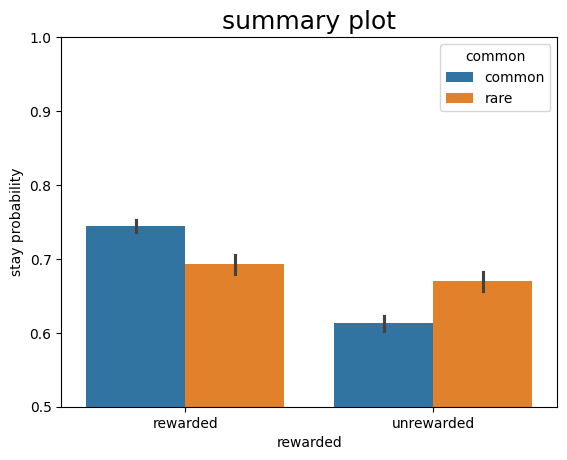

In [21]:

# pooled_data_df = pd.concat(pooled_data)

#print(pooled_data_df)

# pooled_data_df = processed_data#pd.concat(data)

#mask_array = np.stack(all_mask, axis=-1).astype(int)
#print(mask_array)
#np.savetxt(mask_file, mask_array, fmt="%5i", delimiter=',')

with open(mask_file, "wb") as f:
    pkl.dump(valid, f)

plt.figure()
g = sns.barplot(data=plot_df[plot_df["valid"]==True], x="rewarded", y="stayed", hue="common", order=["rewarded", "unrewarded"])
#g.set_xticklabels(names, rotation=45, horizontalalignment='right', fontsize=16)
plt.ylim([0.5,1])
# plt.yticks(np.arange(0,1.1,0.2),fontsize=16)
plt.title("summary plot", fontsize=18)
# plt.savefig(os.path.join(statistics_folder, "behavior_summary_plot_df.svg"),dpi=300)
plt.ylabel("stay probability")
plt.show()

In [22]:
with open(structured_data_file, "wb") as f:
    pkl.dump(structured_data, f)

Save as CSV

In [23]:
processed_data.to_csv(full_data_file)

Read the CSV to test that writing worked

In [24]:
test_data = pd.read_csv(full_data_file)

print("\n\nfull data")
print(test_data)



full data
       Unnamed: 0  subject  trial  valid  choices first stage  \
0               0        0      0   True                    0   
1               1        0      1   True                    0   
2               2        0      2   True                    0   
3               3        0      3   True                    0   
4               4        0      4   True                    0   
...           ...      ...    ...    ...                  ...   
30895       30895      205    120   True                    0   
30896       30896      205    121   True                    1   
30897       30897      205    122   True                    1   
30898       30898      205    123   True                    0   
30899       30899      205    124   True                    0   

       choices second stage  RTs first stage  RTs second stage  \
0                         1             1404              1044   
1                         0              858               496   
2        